# 트리 기반 모델 성능 비교

동일한 전처리 파이프라인을 적용한 뒤, 다양한 트리 기반 모델의 기본(default) 성능을 비교합니다.

**전처리 요약**
1. 결측치 → 같은 시간대 + 같은 기지국 평균 대체
2. 기지국 선별: C, D, H, I
3. 피처 엔지니어링: 시간대 변수(OHE), Lag-1 변수 6개
4. 피처 제거 9개 (VIF 기반)
5. StandardScaler (OHE 변수 제외)
6. Split 8:1:1 (시간순, 셔플 없음)

**비교 모델**: Decision Tree, Random Forest, Extra Trees, Gradient Boosting, AdaBoost, XGBoost, LightGBM, CatBoost

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tree-based models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

## 1. 데이터 로드 및 전처리

In [2]:
# ── 헬퍼 함수 ──
def categorize_hour(hour):
    if 0 <= hour < 7:
        return 'bedtime'
    elif 7 <= hour < 17:
        return 'day'
    else:
        return 'evening'

lag_var_list = ['nummsg3', 'erabaddatt', 'rlculbyte', 'bler_dl', 'attpaging', 'dltransmittedmcsavg']

def create_lag(df, var_list, num_lag=1):
    df['hour'] = df.index.hour
    for lag in range(num_lag):
        for var in var_list:
            df[f'{var}_lag{lag+1}'] = df.groupby('ru_id')[var].shift(1)
            df[f'{var}_lag{lag+1}'] = df.groupby(['ru_id', 'hour'])[f'{var}_lag{lag+1}'].transform(lambda x: x.fillna(x.mean()))
    df.drop('hour', axis=1, inplace=True)
    return df

drop_cols = [
    'rachpreamblea', 'time_of_day_day', 'endcaddsucc', 'erabaddsucc',
    'endcmodbymenbsucc', 'connestabsucc', 'handoversucc',
    'endcmodbysgnbsucc', 'reestabsucc'
]
stations_to_include = ['BaseStationC', 'BaseStationD', 'BaseStationH', 'BaseStationI']

In [3]:
# ── 데이터 로드 ──
Q1_train = pd.read_csv('../Q1_data/Q1_train.csv')
print(f"원본 데이터 shape: {Q1_train.shape}")

# ── 1. 결측치 처리: 같은 시간대 + 같은 기지국 평균 대체 ──
Q1_train['time'] = pd.to_datetime(Q1_train['datetime']).dt.time
Q1_train = Q1_train.sort_values(by=['time', 'ru_id'])
grouped_means = Q1_train.drop('datetime', axis=1).groupby(['time', 'ru_id']).transform('mean')
Q1_train[Q1_train.columns.difference(['datetime'])] = Q1_train[Q1_train.columns.difference(['datetime'])].fillna(grouped_means)
Q1_train = Q1_train.sort_values(by=['datetime', 'ru_id'])
Q1_train.drop('time', axis=1, inplace=True)

# ── 2. 기지국 선별 (C, D, H, I) ──
train_df = Q1_train[Q1_train['ru_id'].isin(stations_to_include)].copy()
print(f"기지국 필터 후 shape: {train_df.shape}")

# 타겟 재배치
target = train_df.pop('uenomax')
train_df.insert(0, target.name, target)

# datetime 변환
train_df['datetime'] = pd.to_datetime(train_df['datetime'], format='%Y-%m-%d %H:%M:%S')

# ── 3. 피처 엔지니어링 ──
# 시간대 변수
train_df['hour'] = train_df['datetime'].dt.hour
train_df['time_of_day'] = train_df['hour'].apply(categorize_hour)
train_df.set_index('datetime', inplace=True)
train_df.drop('hour', axis=1, inplace=True)

# OHE
train_df = pd.get_dummies(train_df, columns=['time_of_day'])

# Lag-1 변수
train_df = create_lag(train_df, lag_var_list, num_lag=1)

# ── 4. 피처 제거 ──
train_df.drop(drop_cols, axis=1, inplace=True)

print(f"전처리 완료 shape: {train_df.shape}")
train_df.head(3)

원본 데이터 shape: (137445, 39)
기지국 필터 후 shape: (68724, 39)
전처리 완료 shape: (68724, 38)


,uenomax,ru_id,scgfail,scgfailratio,erabaddatt,endcaddatt,endcmodbymenbatt,endcmodbysgnbatt,connestabatt,redirectiontolte_coverageout,...,dlreceivedcqiavg,endcrelbymenb,time_of_day_bedtime,time_of_day_evening,nummsg3_lag1,erabaddatt_lag1,rlculbyte_lag1,bler_dl_lag1,attpaging_lag1,dltransmittedmcsavg_lag1
datetime,,,,,,,,,,,,,,,,,,,,,
2023-05-19,4,BaseStationC,0,0.0,13,9,7,18,10,0,...,9.4,9,True,False,37.223922,28.731572,1716.778860,10.861613,1938.233658,8.815716
2023-05-19,4,BaseStationD,0,0.0,29,29,1,18,1,0,...,12.4,28,True,False,26.194715,21.247566,1118.201669,12.473853,1938.233658,7.938804
2023-05-19,1,BaseStationH,0,0.0,10,9,0,1,7,0,...,12.1,10,True,False,14.308762,8.235049,617.915160,7.771627,1917.812239,5.711544


## 2. Train / Validation / Test Split (8:1:1) & Scaling

In [4]:
# ── X, y 분리 ──
X = train_df.drop(['uenomax', 'ru_id'], axis=1)
y = train_df['uenomax']

# ── 8:1:1 시간순 분할 ──
train_size = int(0.8 * len(X))
val_size = int(0.1 * len(X))

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ── 5. StandardScaler (OHE 변수 제외) ──
ohe_cols = ['time_of_day_bedtime', 'time_of_day_evening']
feature_cols = [c for c in X_train.columns if c not in ohe_cols]

scaler = StandardScaler()
scaler.fit(X_train[feature_cols])

def scale_split(df):
    scaled = pd.DataFrame(scaler.transform(df[feature_cols]), columns=feature_cols)
    ohe_reset = df[ohe_cols].reset_index(drop=True)
    return pd.concat([ohe_reset, scaled], axis=1)

scaled_X_train = scale_split(X_train)
scaled_X_val = scale_split(X_val)
scaled_X_test = scale_split(X_test)

print(f"스케일링 완료 — 피처 수: {scaled_X_train.shape[1]}")

Train: (54979, 36), Val: (6872, 36), Test: (6873, 36)
스케일링 완료 — 피처 수: 36


## 3. 모델 학습 및 성능 비교

In [5]:
import time

# ── 비교 모델 정의 (기본 하이퍼파라미터) ──
models = {
    'Decision Tree':      DecisionTreeRegressor(random_state=48),
    'Random Forest':      RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=48),
    'Extra Trees':        ExtraTreesRegressor(n_estimators=200, n_jobs=-1, random_state=48),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, random_state=48),
    'AdaBoost':           AdaBoostRegressor(n_estimators=200, random_state=48),
    'XGBoost':            XGBRegressor(n_estimators=200, n_jobs=-1, random_state=48),
    'LightGBM':           LGBMRegressor(n_estimators=200, n_jobs=-1, random_state=48, verbose=-1),
    'CatBoost':           CatBoostRegressor(iterations=200, random_seed=48, verbose=0),
}

# ── 학습 & 평가 ──
results = []

for name, model in models.items():
    start = time.time()
    model.fit(scaled_X_train, y_train)
    train_time = time.time() - start

    for split_name, X_split, y_split in [('Val', scaled_X_val, y_val), ('Test', scaled_X_test, y_test)]:
        y_pred = np.round(model.predict(X_split)).astype(int)
        results.append({
            'Model': name,
            'Split': split_name,
            'MAE': mean_absolute_error(y_split, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_split, y_pred)),
            'R2': r2_score(y_split, y_pred),
            'Train Time (s)': round(train_time, 2),
        })

results_df = pd.DataFrame(results)
print("학습 및 평가 완료!")

학습 및 평가 완료!


## 4. 결과 비교 표

In [6]:
# ── Validation 기준 성능 비교 표 ──
val_results = results_df[results_df['Split'] == 'Val'].drop('Split', axis=1).set_index('Model')
test_results = results_df[results_df['Split'] == 'Test'].drop('Split', axis=1).set_index('Model')

# Validation & Test MAE를 나란히 표시
comparison = pd.DataFrame({
    'Val MAE': val_results['MAE'],
    'Test MAE': test_results['MAE'],
    'Val RMSE': val_results['RMSE'],
    'Test RMSE': test_results['RMSE'],
    'Val R²': val_results['R2'],
    'Test R²': test_results['R2'],
    'Train Time (s)': val_results['Train Time (s)'],
}).sort_values('Val MAE')

print("=" * 90)
print("트리 기반 모델 성능 비교 (기본 하이퍼파라미터, 반올림 후 정수 예측)")
print("=" * 90)
comparison.round(4)

트리 기반 모델 성능 비교 (기본 하이퍼파라미터, 반올림 후 정수 예측)


,Val MAE,Test MAE,Val RMSE,Test RMSE,Val R²,Test R²,Train Time (s)
Model,,,,,,,
CatBoost,0.4764,0.4957,0.7595,0.7788,0.7781,0.7737,1.10
LightGBM,0.4767,0.4940,0.7591,0.7734,0.7783,0.7769,0.35
Gradient Boosting,0.4836,0.4977,0.7655,0.7783,0.7745,0.7740,34.22
Extra Trees,0.4866,0.5012,0.7658,0.7813,0.7744,0.7723,6.46
XGBoost,0.4919,0.5148,0.7799,0.8032,0.7660,0.7593,0.55
Random Forest,0.4929,0.5034,0.7725,0.7871,0.7704,0.7689,16.30
Decision Tree,0.7162,0.7390,1.0422,1.0814,0.5821,0.5638,0.97
AdaBoost,0.8485,0.8934,1.0706,1.1142,0.5590,0.5369,21.13


## 5. 시각화

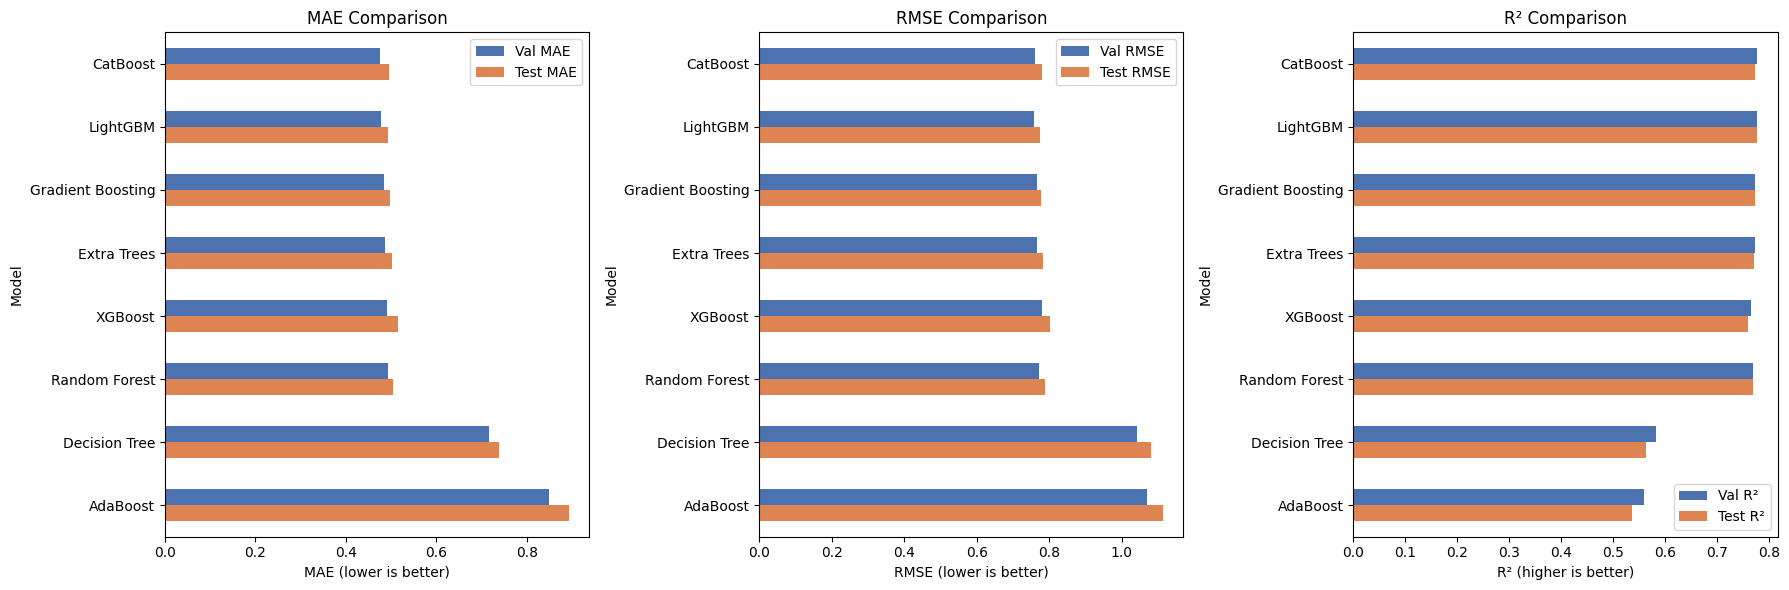

차트 저장 완료: ../모델비교_결과.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# MAE 비교
comparison[['Val MAE', 'Test MAE']].plot(kind='barh', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('MAE Comparison')
axes[0].set_xlabel('MAE (lower is better)')
axes[0].invert_yaxis()

# RMSE 비교
comparison[['Val RMSE', 'Test RMSE']].plot(kind='barh', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('RMSE Comparison')
axes[1].set_xlabel('RMSE (lower is better)')
axes[1].invert_yaxis()

# R² 비교
comparison[['Val R²', 'Test R²']].plot(kind='barh', ax=axes[2], color=['#4C72B0', '#DD8452'])
axes[2].set_title('R² Comparison')
axes[2].set_xlabel('R² (higher is better)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../모델비교_결과.png', dpi=150, bbox_inches='tight')
plt.show()
print("차트 저장 완료: ../모델비교_결과.png")

## 6. 앙상블 모델 성능 비교

앞서 학습된 개별 모델들을 조합하여 Voting(평균) 앙상블과 Stacking 앙상블의 성능을 비교합니다.

**Voting 조합**
- XGBoost + LightGBM (해커톤 최종 모델)
- XGBoost + CatBoost
- LightGBM + CatBoost
- XGBoost + LightGBM + CatBoost
- Random Forest + XGBoost + LightGBM
- 전체 Boosting (GB + AdaBoost + XGB + LGBM + CatBoost)

**Stacking**
- XGBoost + LightGBM + CatBoost → Ridge meta-learner

In [8]:
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import Ridge

# ── 앞서 학습된 개별 모델 재사용 ──
trained = models  # Section 3에서 이미 fit된 dict

# ── Voting 앙상블 조합 정의 ──
ensemble_configs = {
    'Voting: XGB + LGBM': [
        ('XGBoost', XGBRegressor(n_estimators=200, n_jobs=-1, random_state=48)),
        ('LightGBM', LGBMRegressor(n_estimators=200, n_jobs=-1, random_state=48, verbose=-1)),
    ],
    'Voting: XGB + CatBoost': [
        ('XGBoost', XGBRegressor(n_estimators=200, n_jobs=-1, random_state=48)),
        ('CatBoost', CatBoostRegressor(iterations=200, random_seed=48, verbose=0)),
    ],
    'Voting: LGBM + CatBoost': [
        ('LightGBM', LGBMRegressor(n_estimators=200, n_jobs=-1, random_state=48, verbose=-1)),
        ('CatBoost', CatBoostRegressor(iterations=200, random_seed=48, verbose=0)),
    ],
    'Voting: XGB + LGBM + CatBoost': [
        ('XGBoost', XGBRegressor(n_estimators=200, n_jobs=-1, random_state=48)),
        ('LightGBM', LGBMRegressor(n_estimators=200, n_jobs=-1, random_state=48, verbose=-1)),
        ('CatBoost', CatBoostRegressor(iterations=200, random_seed=48, verbose=0)),
    ],
    'Voting: RF + XGB + LGBM': [
        ('RandomForest', RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=48)),
        ('XGBoost', XGBRegressor(n_estimators=200, n_jobs=-1, random_state=48)),
        ('LightGBM', LGBMRegressor(n_estimators=200, n_jobs=-1, random_state=48, verbose=-1)),
    ],
    'Voting: All Boosting': [
        ('GB', GradientBoostingRegressor(n_estimators=200, random_state=48)),
        ('AdaBoost', AdaBoostRegressor(n_estimators=200, random_state=48)),
        ('XGBoost', XGBRegressor(n_estimators=200, n_jobs=-1, random_state=48)),
        ('LightGBM', LGBMRegressor(n_estimators=200, n_jobs=-1, random_state=48, verbose=-1)),
        ('CatBoost', CatBoostRegressor(iterations=200, random_seed=48, verbose=0)),
    ],
}

# ── Voting 앙상블 학습 & 평가 ──
ensemble_results = []

for name, estimators in ensemble_configs.items():
    voting = VotingRegressor(estimators=estimators)
    start = time.time()
    voting.fit(scaled_X_train, y_train)
    train_time = time.time() - start

    for split_name, X_split, y_split in [('Val', scaled_X_val, y_val), ('Test', scaled_X_test, y_test)]:
        y_pred = np.round(voting.predict(X_split)).astype(int)
        ensemble_results.append({
            'Model': name,
            'Split': split_name,
            'MAE': mean_absolute_error(y_split, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_split, y_pred)),
            'R2': r2_score(y_split, y_pred),
            'Train Time (s)': round(train_time, 2),
        })
    print(f"  {name} 완료 ({train_time:.1f}s)")

# ── Stacking 앙상블 (XGB + LGBM + CatBoost → Ridge) ──
stacking = StackingRegressor(
    estimators=[
        ('XGBoost', XGBRegressor(n_estimators=200, n_jobs=-1, random_state=48)),
        ('LightGBM', LGBMRegressor(n_estimators=200, n_jobs=-1, random_state=48, verbose=-1)),
        ('CatBoost', CatBoostRegressor(iterations=200, random_seed=48, verbose=0)),
    ],
    final_estimator=Ridge(),
    cv=3,
    n_jobs=-1,
)

start = time.time()
stacking.fit(scaled_X_train, y_train)
train_time = time.time() - start

for split_name, X_split, y_split in [('Val', scaled_X_val, y_val), ('Test', scaled_X_test, y_test)]:
    y_pred = np.round(stacking.predict(X_split)).astype(int)
    ensemble_results.append({
        'Model': 'Stacking: XGB+LGBM+CB → Ridge',
        'Split': split_name,
        'MAE': mean_absolute_error(y_split, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_split, y_pred)),
        'R2': r2_score(y_split, y_pred),
        'Train Time (s)': round(train_time, 2),
    })
print(f"  Stacking 완료 ({train_time:.1f}s)")

ensemble_results_df = pd.DataFrame(ensemble_results)
print("\n앙상블 학습 및 평가 완료!")

  Voting: XGB + LGBM 완료 (0.8s)
  Voting: XGB + CatBoost 완료 (1.3s)
  Voting: LGBM + CatBoost 완료 (1.3s)
  Voting: XGB + LGBM + CatBoost 완료 (1.8s)
  Voting: RF + XGB + LGBM 완료 (17.4s)
  Voting: All Boosting 완료 (56.6s)
  Stacking 완료 (9.5s)

앙상블 학습 및 평가 완료!


### 6-1. 앙상블 결과 비교 표

In [9]:
# ── 앙상블 성능 비교 표 ──
ens_val = ensemble_results_df[ensemble_results_df['Split'] == 'Val'].drop('Split', axis=1).set_index('Model')
ens_test = ensemble_results_df[ensemble_results_df['Split'] == 'Test'].drop('Split', axis=1).set_index('Model')

ensemble_comparison = pd.DataFrame({
    'Val MAE': ens_val['MAE'],
    'Test MAE': ens_test['MAE'],
    'Val RMSE': ens_val['RMSE'],
    'Test RMSE': ens_test['RMSE'],
    'Val R²': ens_val['R2'],
    'Test R²': ens_test['R2'],
    'Train Time (s)': ens_val['Train Time (s)'],
}).sort_values('Val MAE')

print("=" * 90)
print("앙상블 모델 성능 비교 (기본 하이퍼파라미터, 반올림 후 정수 예측)")
print("=" * 90)
ensemble_comparison.round(4)

앙상블 모델 성능 비교 (기본 하이퍼파라미터, 반올림 후 정수 예측)


,Val MAE,Test MAE,Val RMSE,Test RMSE,Val R²,Test R²,Train Time (s)
Model,,,,,,,
Voting: XGB + LGBM + CatBoost,0.4694,0.4887,0.7520,0.7691,0.7824,0.7794,1.75
Voting: XGB + LGBM,0.4719,0.4881,0.7558,0.7711,0.7802,0.7782,0.75
Voting: XGB + CatBoost,0.4729,0.4912,0.7568,0.7733,0.7796,0.7769,1.33
Voting: LGBM + CatBoost,0.4742,0.4906,0.7559,0.7695,0.7801,0.7791,1.26
Stacking: XGB+LGBM+CB → Ridge,0.4745,0.4921,0.7569,0.7708,0.7796,0.7783,9.45
Voting: RF + XGB + LGBM,0.4750,0.4897,0.7543,0.7695,0.7811,0.7791,17.37
Voting: All Boosting,0.4908,0.5072,0.7642,0.7785,0.7753,0.7739,56.57


### 6-2. 앙상블 시각화

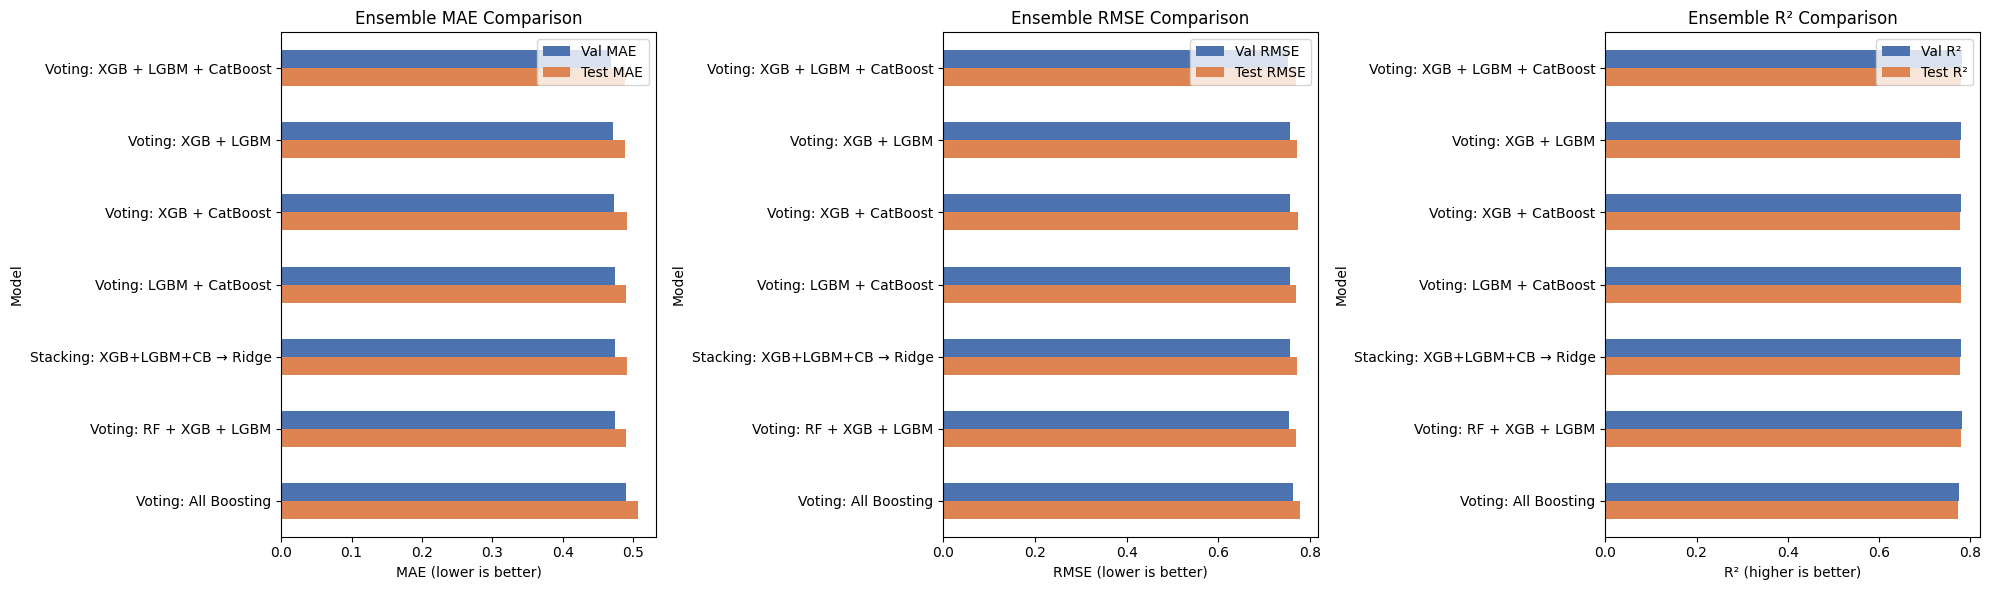

차트 저장 완료: ../앙상블비교_결과.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ensemble_comparison[['Val MAE', 'Test MAE']].plot(kind='barh', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Ensemble MAE Comparison')
axes[0].set_xlabel('MAE (lower is better)')
axes[0].invert_yaxis()

ensemble_comparison[['Val RMSE', 'Test RMSE']].plot(kind='barh', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Ensemble RMSE Comparison')
axes[1].set_xlabel('RMSE (lower is better)')
axes[1].invert_yaxis()

ensemble_comparison[['Val R²', 'Test R²']].plot(kind='barh', ax=axes[2], color=['#4C72B0', '#DD8452'])
axes[2].set_title('Ensemble R² Comparison')
axes[2].set_xlabel('R² (higher is better)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../앙상블비교_결과.png', dpi=150, bbox_inches='tight')
plt.show()
print("차트 저장 완료: ../앙상블비교_결과.png")